# Phase 1: Exploratory Data Analysis (EDA) - Irrigation Need Prediction
**Author:** Belal Said  
**Dataset:** Kaggle S6E4 (Environmental and Soil Conditions)

## Objective
The goal of this notebook is to understand the structural characteristics of the dataset before applying preprocessing or machine learning architectures. Specifically, we are investigating:
1. **Target Distribution:** Is the `Irrigation_Need` class balanced? 
2. **Correlation Analysis:** Which environmental features exhibit multicollinearity?

In [ ]:
# Import necessary core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
df = pd.read_csv('../data/raw/train.csv')

display(df.head())
print("\nDataset Shape:", df.shape)
print("\nData Types and Missing Values:")
df.info()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low



Dataset Shape: (630000, 21)

Data Types and Missing Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  object 
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  object 
 12  Crop_Growth_Stage        630000 non-null  object 
 13

## 1. Target Distribution & Balance
Understanding the distribution of the `Irrigation_Need` category is critical. If the classes are heavily imbalanced, standard accuracy metrics will be deceptive, justifying our use of Balanced Accuracy during the evaluation phase.

--- CLASS PERCENTAGES ---
Irrigation_Need
Low       58.72%
Medium    37.95%
High       3.33%
Name: proportion, dtype: object




C:\Users\DELL\AppData\Local\Temp\ipykernel_20096\4262757837.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x=target_col, palette="viridis", order=class_counts.index)


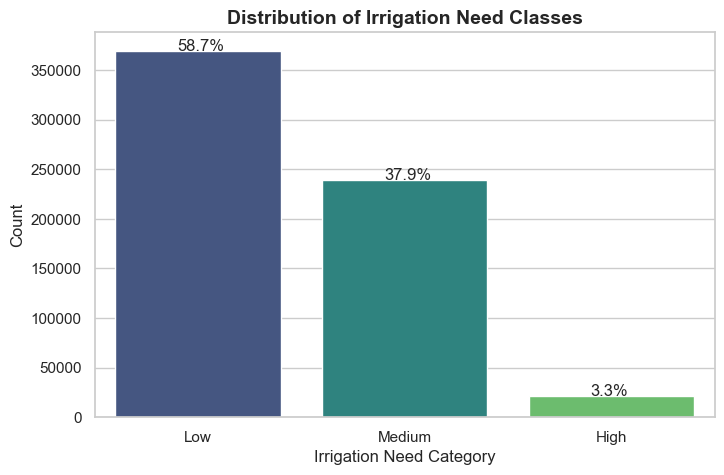

In [ ]:
# Analyze the distribution of the target variable
target_col = 'Irrigation_Need'

# Calculate percentages
class_counts = df[target_col].value_counts()
class_percentages = df[target_col].value_counts(normalize=True) * 100

print("--- CLASS PERCENTAGES ---")
print(class_percentages.round(2).astype(str) + '%')
print("\n")

# Plot the distribution
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x=target_col, palette="viridis", order=class_counts.index)
plt.title('Distribution of Irrigation Need Classes', fontsize=14, fontweight='bold')
plt.ylabel('Count')
plt.xlabel('Irrigation Need Category')

# Add percentage labels on top of the bars
for p in ax.patches:
    percentage = f'{100 * p.get_height() / len(df):.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.1
    y = p.get_y() + p.get_height() + 100
    ax.annotate(percentage, (x, y), size=12)

plt.show()

## 2. Feature Correlation & Multicollinearity
We must identify which environmental features have the strongest linear relationships with each other. High multicollinearity (e.g., correlation > 0.8) can cause instability in linear models like Logistic Regression.

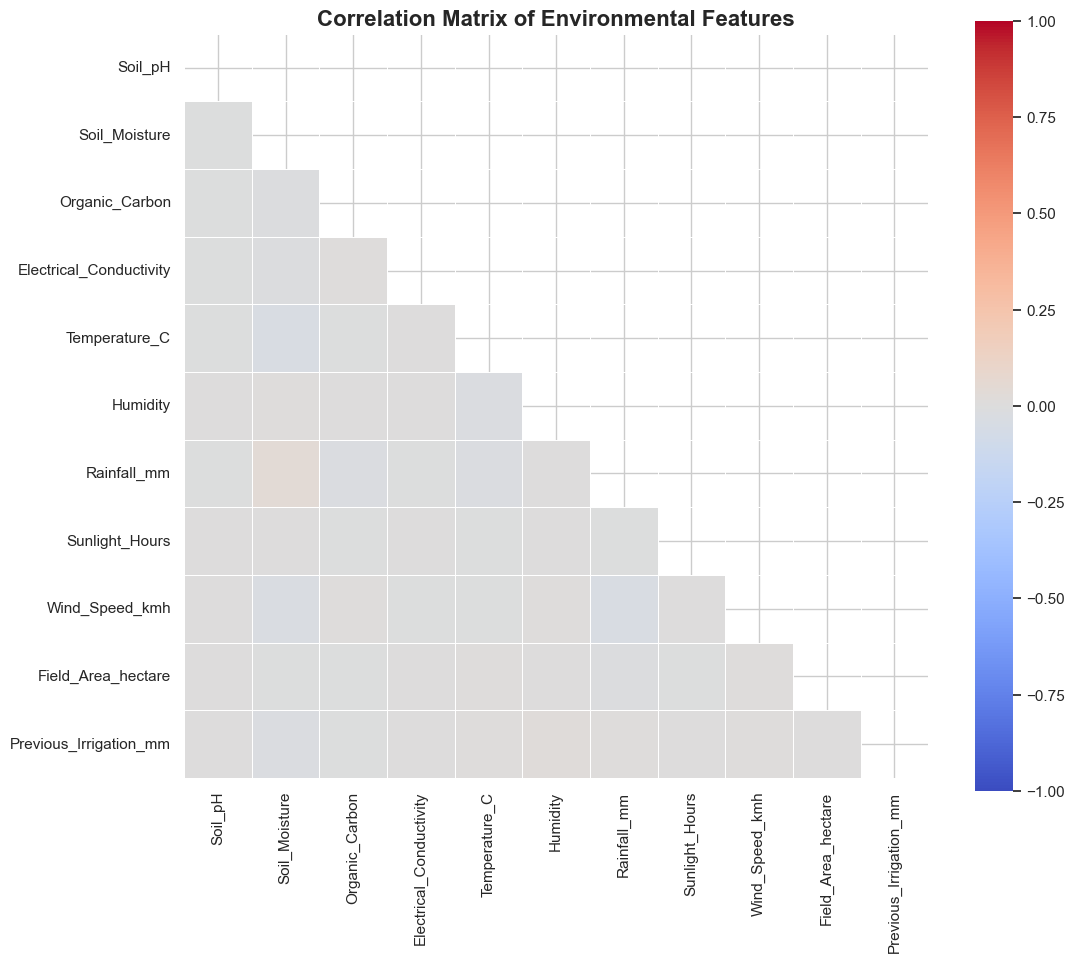

--- HIGHLY CORRELATED FEATURES (>0.8) ---
No features have a correlation higher than 0.8.


In [6]:
# Select only numerical columns for correlation and drop 'id'
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['id'], errors='ignore')

# Calculate the correlation matrix using absolute values to catch high negative correlations too
corr_matrix_abs = numeric_df.corr().abs()
corr_matrix_raw = numeric_df.corr()

# Create a mask to hide the upper triangle (it's redundant)
mask = np.triu(np.ones_like(corr_matrix_raw, dtype=bool))

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix_raw, mask=mask, annot=False, cmap='coolwarm', 
            vmax=1.0, vmin=-1.0, center=0, square=True, linewidths=.5)
plt.title('Correlation Matrix of Environmental Features', fontsize=16, fontweight='bold')
plt.show()

# --- Automated Multicollinearity Detection ---
print("--- HIGHLY CORRELATED FEATURES (>0.8) ---")

# Extract the upper triangle of the absolute matrix to avoid duplicate pairs
upper_tri = corr_matrix_abs.where(np.triu(np.ones(corr_matrix_abs.shape), k=1).astype(bool))

# Find features with correlation greater than 0.8
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.8)]

if not to_drop:
    print("No features have a correlation higher than 0.8.")
else:
    print("These specific feature pairs exhibit high multicollinearity:")
    for col in to_drop:
        # Find exactly what it is correlated with
        correlated_with = upper_tri.index[upper_tri[col] > 0.8].tolist()
        for correlated_col in correlated_with:
            val = corr_matrix_raw.loc[col, correlated_col]
            print(f" - '{col}' & '{correlated_col}' (Correlation: {val:.3f})")